In [12]:
#Imports and Setup
import sys
from pathlib import Path

#Ensure src/ is on the path
sys.path.append(str(Path("src").resolve()))

import pandas as pd
from src.API_Call import get_country_metadata
from src.analysis import clustering_and_regression
from src.table_setup import build_merged_dataset
from src.analysis import load_merged, basic_eda, clustering_and_regression

In [13]:
#Get API Data
rest_api = get_country_metadata()
rest_api.head()

Saved 250 rows to data/country_metadata.csv


,Country,Country_Code,Region,Sub-region,Population
0,Anguilla,AIA,Americas,Caribbean,16010
1,Guatemala,GTM,Americas,Central America,18079810
2,Gambia,GMB,Africa,Western Africa,2422712
3,Mexico,MEX,Americas,North America,130575786
4,Malawi,MWI,Africa,Eastern Africa,20734262


In [14]:
#Here we will merge the datasets together and save it in its own file
merged_df = build_merged_dataset()
merged_df.head()

Saved Merged Dataset to data/merged_work_happiness_countries.csv with 1617 rows


,country,work_hours,happiness_score,Country,Country_Code,Region,Sub-region,Population
0,Albania,2094.197778,5.662,Albania,ALB,Europe,Southeast Europe,2363314.0
1,Albania,2094.197778,5.411,Albania,ALB,Europe,Southeast Europe,2363314.0
2,Albania,2094.197778,5.304,Albania,ALB,Europe,Southeast Europe,2363314.0
3,Albania,2094.197778,5.277,Albania,ALB,Europe,Southeast Europe,2363314.0
4,Albania,2094.197778,5.199,Albania,ALB,Europe,Southeast Europe,2363314.0


In [15]:
#We will now proceed to call the merged dataset
merged = load_merged()
merged.head()

,country,work_hours,happiness_score,Country,Country_Code,Region,Sub-region,Population
0,Albania,2094.197778,5.662,Albania,ALB,Europe,Southeast Europe,2363314.0
1,Albania,2094.197778,5.411,Albania,ALB,Europe,Southeast Europe,2363314.0
2,Albania,2094.197778,5.304,Albania,ALB,Europe,Southeast Europe,2363314.0
3,Albania,2094.197778,5.277,Albania,ALB,Europe,Southeast Europe,2363314.0
4,Albania,2094.197778,5.199,Albania,ALB,Europe,Southeast Europe,2363314.0


(1617, 8)
country            0.000000
work_hours         0.000000
happiness_score    0.000000
Country            0.008658
Country_Code       0.008658
Region             0.008658
Sub-region         0.008658
Population         0.008658
dtype: float64
        work_hours  happiness_score    Population
count  1617.000000      1617.000000  1.603000e+03
mean   1926.196888         5.613495  6.122062e+07
std     311.946948         1.112707  1.892678e+08
min    1363.250000         2.392000  3.918100e+05
25%    1648.260000         4.707000  5.606944e+06
50%    1933.195556         5.693000  1.807981e+07
75%    2151.861111         6.474000  4.590542e+07
max    2650.687500         7.856000  1.417492e+09


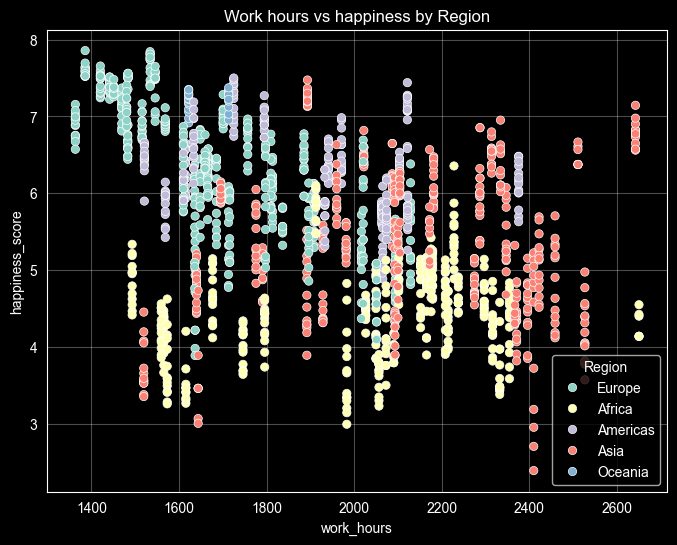

                 work_hours  happiness_score
work_hours         1.000000        -0.414414
happiness_score   -0.414414         1.000000


In [9]:
#Perform basic exploratory data analysis
basic_eda(merged)

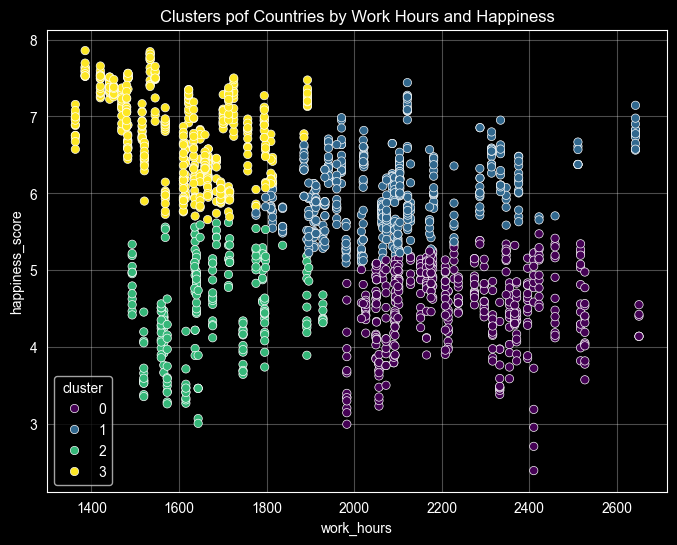

          work_hours  happiness_score
cluster                              
0        2238.436417         4.520429
1        2090.945966         5.991231
2        1674.922767         4.495855
3        1608.493340         6.768648
Coefficient:  [-0.00135201]
Intercept:  [8.20738749]
R^2 train:  0.14566085917157223
R^2 test:  0.26131849377428873
         work_hours  happiness_score
cluster                             
0           2238.44             4.52
1           2090.95             5.99
2           1674.92             4.50
3           1608.49             6.77
cluster
0    443
1    455
2    228
3    491
Name: count, dtype: int64
Region   Africa  Americas  Asia  Europe  Oceania
cluster                                         
0           247         3   146      33        0
1            28       137   192      98        0
2           107         3    75      43        0
3             0        91    32     340       28


In [18]:
#Clustering with KMeans where K=4
clustering_and_regression(merged)